# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

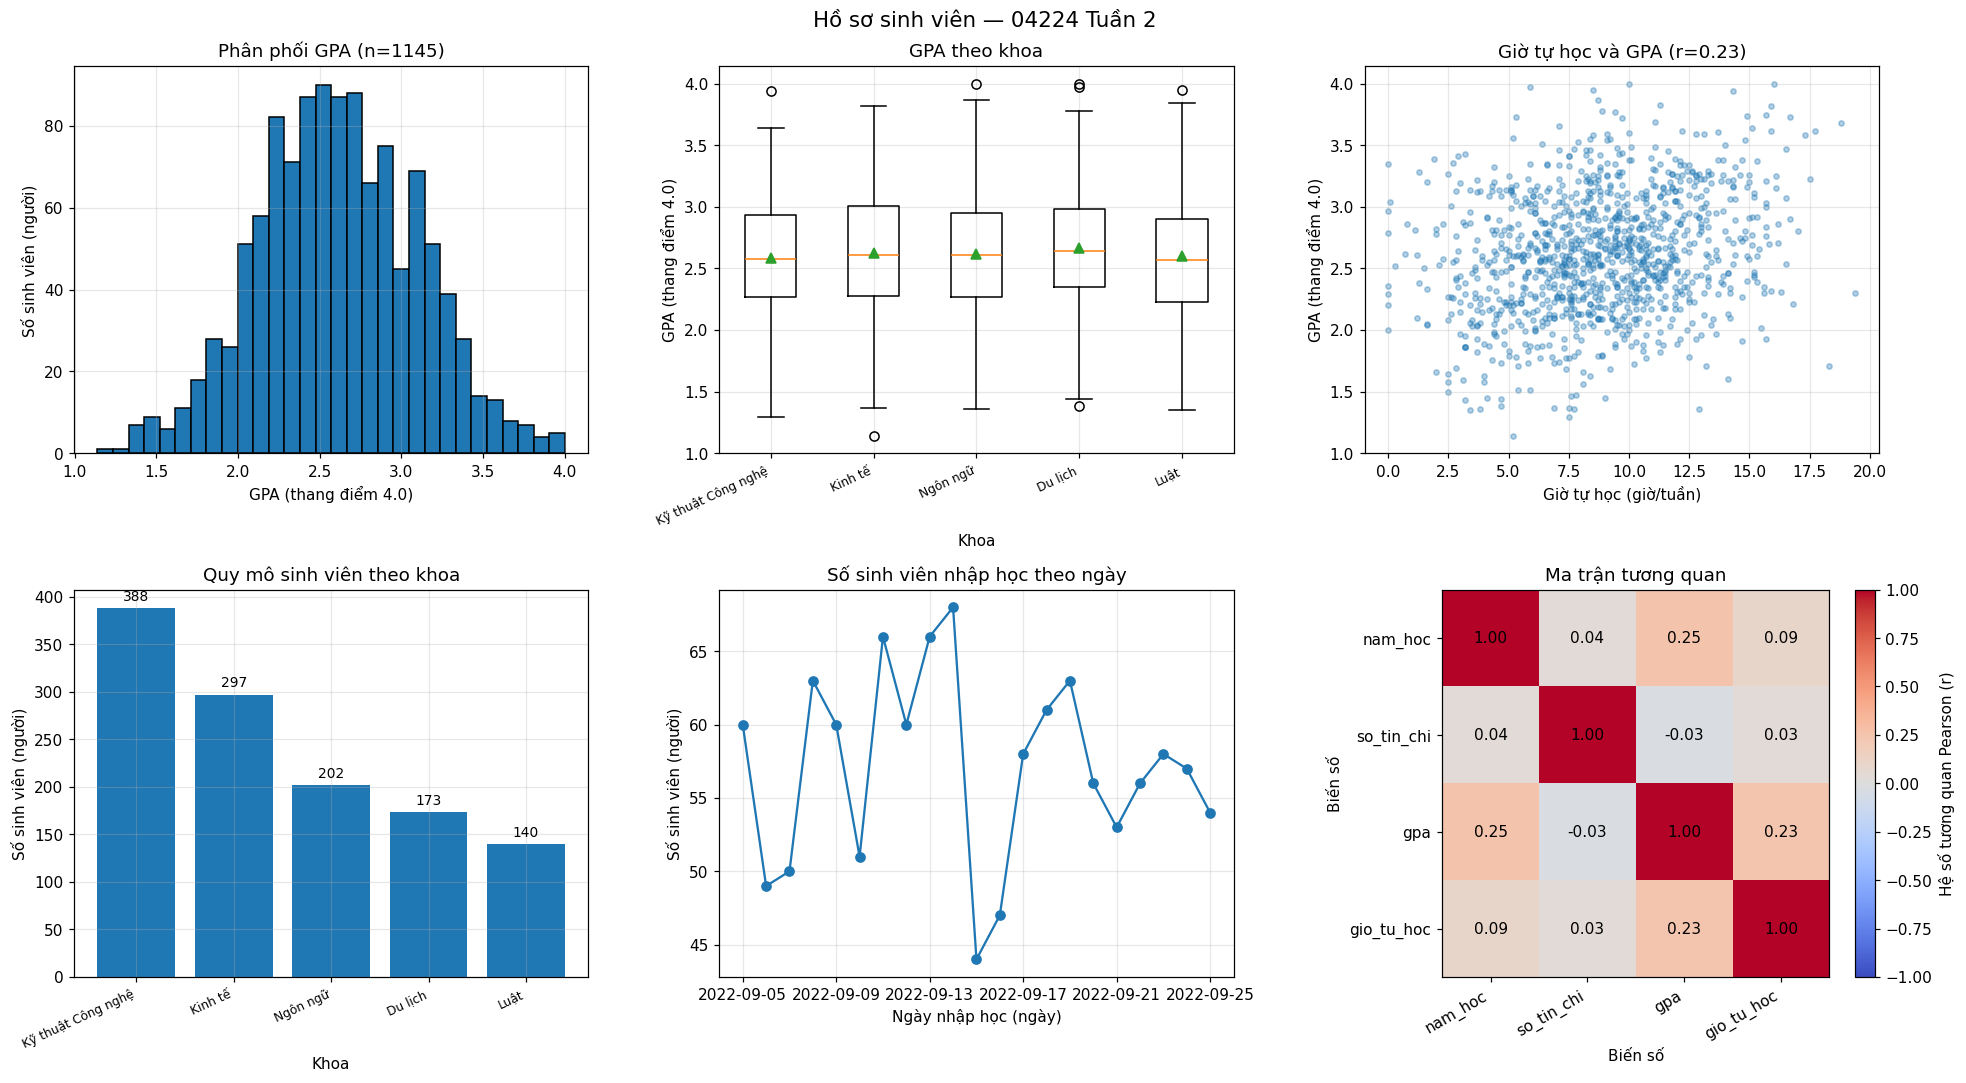

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])  # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, edgecolor="black")
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số sinh viên (người)")
ax.set_title("Phân phối GPA (n=1145)")

# (2) Box plot — GPA theo khoa
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
data = [sv.loc[sv["khoa"] == f, "gpa"].dropna() for f in faculties]
ax.boxplot(data, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("GPA theo khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35)
ax.set_xlabel("Giờ tự học (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Giờ tự học và GPA (r=%.2f)" % r)

# (4) Bar — số sinh viên theo khoa
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
bars = ax.bar(counts.index, counts.values)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Khoa")
ax.set_ylabel("Số sinh viên (người)")
ax.set_title("Quy mô sinh viên theo khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index, enrol.values, marker="o")
ax.set_xlabel("Ngày nhập học (ngày)")
ax.set_ylabel("Số sinh viên (người)")
ax.set_title("Số sinh viên nhập học theo ngày")

# (6) Heatmap — ma trận tương quan
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=30, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center")
ax.set_xlabel("Biến số")
ax.set_ylabel("Biến số")
ax.set_title("Ma trận tương quan")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan Pearson (r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

1. Histogram GPA: GPA tập trung quanh 2.6, phần lớn sinh viên nằm khoảng 2.0–3.2 và rất ít sinh viên ở mức trên 3.5.
2. Box plot theo khoa: GPA giữa các khoa khá gần nhau; Du lịch có trung vị cao hơn, còn Luật có độ phân tán lớn hơn tương đối.
3. Scatter giờ tự học – GPA: Có tương quan dương nhưng yếu (r≈0.23), tức giờ tự học nhiều hơn có xu hướng đi kèm GPA cao hơn nhưng không giải thích toàn bộ GPA.
4. Bar quy mô khoa: Kỹ thuật Công nghệ có nhiều sinh viên nhất (388), Luật ít nhất (140).
5. Line nhập học: Số sinh viên nhập học tập trung mạnh trong tháng 9/2022 và đạt đỉnh 68 sinh viên vào 14/09/2022.
6. Heatmap tương quan: `nam_hoc` tương quan dương yếu với GPA (r≈0.25), `gio_tu_hoc` cũng dương yếu (r≈0.23), còn `so_tin_chi` gần như không tương quan với GPA.


---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng."""
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        vc = s.value_counts(dropna=True).head(k)
        if vc.empty:
            top = ""
        else:
            parts = [f"{repr(idx)} x{int(cnt)}" for idx, cnt in vc.items()]
            top = ", ".join(parts)
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_missing": int(s.isna().sum()),
            "pct_missing": round((s.isna().sum() / n * 100) if n else 0, 2),
            "n_unique": int(s.nunique(dropna=True)),
            "top_values": top,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")


In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2201184 x1, 2201183 x1, 2201182 x1, 2201181 x1...
ho_ten          object          0         0.00       861  'Phạm Thị Dũng' x5, 'Huỳnh Gia Vy' x5, 'Hoàng ...
khoa            object          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp         object         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

1. `thanh_tien` có `dtype` không đúng vì một phần giá trị chứa ký tự tiền tệ `đ`, nên pandas đọc cả cột thành chuỗi; `so_luong` là `float64` vì có ô thiếu.
2. `ma_don` có 900 giá trị duy nhất nhưng tệp có 928 dòng, cho thấy có 28 dòng bị trùng.
3. `kenh` có 4 cách viết nhưng thực tế chỉ có 2 kênh: `Online` và `Cửa hàng`.


---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))
print()

print("Dòng trùng hoàn toàn:", int(df.duplicated().sum()))
print("Các cách viết `kenh`:", df["kenh"].value_counts(dropna=False).to_dict())
money_text = df["thanh_tien"].astype(str).str.contains("đ", regex=False)
print("Dòng `thanh_tien` có chữ `đ`:", int(money_text.sum()))
dmy_rows = df["ngay"].astype(str).str.fullmatch(r"\d{2}/\d{2}/\d{4}")
print("Dòng `ngay` dạng DD/MM/YYYY:", int(dmy_rows.sum()))


Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don       object          0         0.00       900  'DH00458' x2, 'DH00682' x2, 'DH00109' x2, 'DH0...
san_pham     object          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh         object          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp      object         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay         object          0         0.00       415  '2024-11-11' x7, '2024-09-26' x7, '2024-02-29'...
thanh_tien   object          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28
assert len(df) == 900
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique


Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

key = df["kenh"].astype(str).str.strip().str.casefold()
print("\nSau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng",
}

df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2
assert df["kenh"].isna().sum() == 0
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330


Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Sau strip + casefold còn lại: ['cua hang', 'cửa hàng', 'online']

Sau : 'Online' x570, 'Cửa hàng' x330


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ", regex=False)
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"].astype(str)
      .str.replace("đ", "", regex=False)
      .str.replace(".", "", regex=False)
      .str.strip(),
    errors="raise"
)

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000


Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))

parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

bad_date_cost = int(df.loc[parsed.isna(), "thanh_tien"].sum())
print("Tổng thanh_tien của 7 dòng ngày sai:", format(bad_date_cost, ",").replace(",", "."), "đ")

# Giữ nguyên 7 dòng để không làm mất giao dịch/doanh thu; chỉ đánh dấu ngày không xác định.
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900


YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d", at position 5. You might want to
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}
Tổng thanh_tien của 7 dòng ngày sai: 44.400.000 đ


### Quyết định của bạn về 7 ngày không tồn tại

1. `errors="coerce"` cho 120 `NaT` vì pandas không nhận đúng 113 dòng DD/MM khi định dạng bị trộn; 113 ngày hợp lệ bị chuyển thành `NaT` ngoài 7 ngày thật sự sai.
2. Chọn **giữ dòng, để `ngay = NaT`**.
3. Lý do: 7 dòng vẫn có dữ liệu giao dịch hợp lệ; xóa dòng sẽ làm mất 44.400.000 đ doanh thu. Chưa biết ngày không có nghĩa là toàn bộ giao dịch sai.
4. Giữ dòng giúp tổng doanh thu năm không bị giảm và các tổng doanh thu theo kênh vẫn đầy đủ. Khi vẽ theo tháng, 7 giao dịch này không thể phân bổ vào tháng nào cho đến khi có ngày đúng.


## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

qty_implied = df["thanh_tien"] / df["don_gia"]
print("qty_implied là số nguyên ở mọi dòng:", bool((qty_implied % 1 == 0).all()))
print("Khoảng qty suy ra:", int(qty_implied.min()), "->", int(qty_implied.max()))

known = df["so_luong"].notna()
matched = int((df.loc[known, "so_luong"] == qty_implied.loc[known]).sum())
print("Dòng `so_luong` có sẵn khớp phép suy luận:", matched, "/", int(known.sum()))

need = df["so_luong"].isna()
df.loc[need, "so_luong"] = qty_implied.loc[need]

df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9


so_luong thiếu: 30
tinh_tp  thiếu: 52
qty_implied là số nguyên ở mọi dòng: True
Khoảng qty suy ra: 1 -> 5
Dòng `so_luong` có sẵn khớp phép suy luận: 863 / 870

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

1. `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong [1, 5]. Có 863/870 dòng `so_luong` đã có sẵn khớp với giá trị suy ra; 30 ô thiếu vì vậy có thể khôi phục chính xác.
2. Không nên dùng `fillna(median)` vì giá trị thật có thể suy ra trực tiếp từ `thanh_tien / don_gia`; dùng median sẽ thay thế dữ liệu thật bằng ước lượng.
3. Với `tinh_tp`, chọn nhãn riêng **"Không rõ"**.
4. Không nên dùng mode vì sẽ bịa 52 đơn cho tỉnh phổ biến nhất và làm sai bảng xếp hạng doanh thu theo tỉnh; `dropna()` lại làm mất 52 giao dịch.


## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))

suspect = df[flag].copy()
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien", "qty_implied"]].to_string(index=False))

print("\nKết luận bằng chứng:")
print("- 4 dòng so_luong=500 có thanh_tien tương ứng với qty thực từ 1 đến 5, không phải 500 -> lỗi nhập liệu.")
print("- 3 dòng so_luong=-2 có thanh_tien dương, nên không phải giao dịch trả lại theo giả thuyết -> lỗi nhập liệu.")

# Khôi phục giá trị đúng từ ràng buộc thanh_tien = so_luong * don_gia.
df.loc[flag, "so_luong"] = (df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]).astype(int)
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all()
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0


Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
 ma_don   san_pham  so_luong  don_gia  thanh_tien  qty_implied
DH00299      Chuột      -2.0   250000      250000            1
DH00165   Tai nghe      -2.0   690000     2070000            3
DH00089     Webcam     500.0   890000     4450000            5
DH00652   Tai nghe     500.0   690000      690000            1
DH00263     Webcam     500.0   890000     4450000            5
DH00764 Ổ cứng SSD     500.0  1450000     7250000            5
DH00226   Bàn phím      -2.0   450000     1800000            4

Kết luận bằng chứng:
- 4 dòng so_luong=500 có thanh_tien tương ứng với qty thực từ 1 đến 5, không phải 500 -> lỗi nhập liệu.
- 3 dòng so_luong=-2 có thanh_tien dương, nên không phải giao dịch trả lại theo giả thuyết -> lỗi nhập liệu.

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}


### Lập luận của bạn về 7 dòng ngoại lai

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết “đơn sỉ thật” dự đoán `thanh_tien = 500 × don_gia`.
- Thực tế các dòng chỉ có `thanh_tien` tương ứng với số lượng suy ra 1 hoặc 5.
- Kết luận: đây là lỗi nhập liệu; có thể khôi phục số lượng đúng từ `thanh_tien / don_gia`.

**Nhóm B — 3 dòng `so_luong = -2`**
- Nếu là hàng trả lại thật thì `thanh_tien` phải mang dấu âm.
- Thực tế `thanh_tien` đều dương và suy ra số lượng 1–4.
- Kết luận: đây là lỗi nhập liệu; khôi phục số lượng đúng từ ràng buộc kế toán.

**Câu hỏi cuối:** Nếu `so_luong = 500` và `thanh_tien = 500 × don_gia` thì không được tự động xóa; cần xem đó là đơn sỉ hợp lệ và giữ nguyên nếu các quy tắc nghiệp vụ cho phép.


## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")


Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'object', 'san_pham': 'object', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'object', 'tinh_tp': 'object', 'ngay': 'datetime64[ns]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | Xóa 28 dòng trùng hoàn toàn | Hai dòng giống cả 8 cột là bản ghi lặp khi gộp dữ liệu | 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh | `strip` + `casefold` + ánh xạ `Cua hang` | Chuẩn hóa cùng một kênh về một nhãn, không tự suy đoán cách viết mới | 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | Bỏ `đ`, bỏ dấu `.`, ép sang số | Dấu `.` là phân cách hàng nghìn; cần số để tính toán | `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng | Dùng `format="mixed", dayfirst=True` | Cho pandas biết cột có nhiều định dạng và DD/MM | Đọc đúng 893 ngày |
| 5 | 7 dòng ghi `31/02/2024` | Giữ dòng, đặt `ngay = NaT` | Giao dịch vẫn có giá trị; chỉ ngày là không xác định | Giữ 900 dòng; thiếu 7 ngày |
| 6 | `so_luong` thiếu 30 ô | Suy ra bằng `thanh_tien / don_gia` | Quan hệ kế toán cho giá trị chính xác, không cần ước lượng | 30 → 0 thiếu |
| 7 | `tinh_tp` thiếu 52 ô | Điền nhãn `Không rõ` | Không có cột khác để suy ra tỉnh; giữ nguyên sự thật chưa biết | 52 → 0 thiếu; 9 nhãn |
| 8 | `so_luong` có 4 giá trị `500` | Khôi phục bằng `thanh_tien / don_gia` | Bằng chứng cho thấy 500 là lỗi nhập liệu | Về [1,5] |
| 9 | `so_luong` có 3 giá trị `-2` | Khôi phục bằng `thanh_tien / don_gia` | `thanh_tien` dương nên không phù hợp với hàng trả lại | Về [1,5] |

1. Quyết định có thể làm người khác ra số khác rõ nhất là cách xử lý 7 ngày `31/02/2024`; xóa dòng sẽ làm doanh thu giảm 44.400.000 đ.
2. Quyết định kém chắc chắn nhất là 7 ngày không tồn tại; cần nguồn dữ liệu gốc/hóa đơn để xác nhận ngày thực tế.
3. Notebook có thể chạy lại nếu tệp đầu vào vẫn giữ đúng cấu trúc và các cách viết đã biết. Nếu xuất hiện định dạng/kênh mới, cần cập nhật ánh xạ hoặc quy tắc chuẩn hóa.


---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
g = sv.groupby("nam_hoc")["gpa"]
pattern = g.agg(
    n_students="size",
    n_missing=lambda s: int(s.isna().sum()),
    gpa_mean_observed="mean"
)
pattern["missing_rate_%"] = (pattern["n_missing"] / pattern["n_students"] * 100).round(2)
pattern = pattern[["n_students", "n_missing", "missing_rate_%", "gpa_mean_observed"]]
print(pattern)

print("\nTổng thiếu:", int(sv["gpa"].isna().sum()))
print("Tỷ lệ thiếu:", round(sv["gpa"].isna().mean() * 100, 2), "%")
print("Tỷ lệ thiếu không đều giữa các năm; năm 1 cao nhất.")


         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80           2.481522
2               318          9            2.83           2.535178
3               285          4            1.40           2.693701
4               236          3            1.27           2.809528

Tổng thiếu: 55
Tỷ lệ thiếu: 4.58 %
Tỷ lệ thiếu không đều giữa các năm; năm 1 cao nhất.


In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]
A = sv.dropna(subset=["gpa"])["gpa"]
B = original.fillna(original.mean())
C = original.fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

summary = pd.DataFrame({
    "Gốc": original,
    "(a)": A,
    "(b)": B,
    "(c)": C
}).agg(["count", "mean", "std", "median"]).T.round(4)
print(summary)

by_year = pd.DataFrame({
    "quan sát được": sv.groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung": sv.assign(g=B).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm": sv.assign(g=C).groupby("nam_hoc")["g"].mean()
})
by_year["lệch (b)"] = by_year["(b) TB chung"] - by_year["quan sát được"]
print("\n", by_year.round(4))

print("\nTỷ trọng năm 1 trước:", round((sv["nam_hoc"] == 1).mean(), 4))
print("Tỷ trọng năm 1 sau (a):", round((sv.dropna(subset=["gpa"])["nam_hoc"] == 1).mean(), 4))


      count    mean     std  median
Gốc  1145.0  2.6148  0.4871  2.6000
(a)  1145.0  2.6148  0.4871  2.6000
(b)  1200.0  2.6148  0.4758  2.6148
(c)  1200.0  2.6106  0.4766  2.5800

          quan sát được  (b) TB chung  (c) TB nhóm  lệch (b)
nam_hoc                                                    
1               2.4815        2.4959       2.4815    0.0144
2               2.5352        2.5374       2.5352    0.0023
3               2.6937        2.6926       2.6937   -0.0011
4               2.8095        2.8071       2.8095   -0.0025

Tỷ trọng năm 1 trước: 0.3008
Tỷ trọng năm 1 sau (a): 0.2812


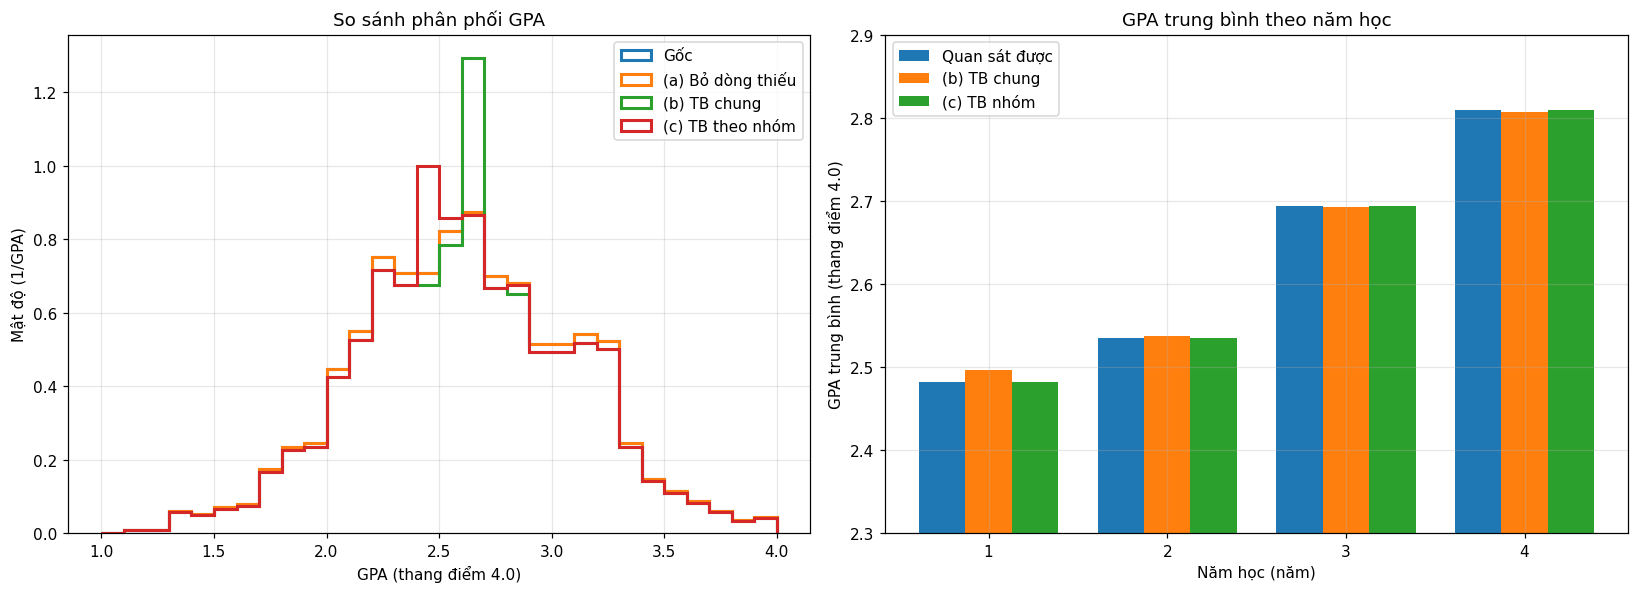

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)
for series, label in [(original, "Gốc"), (A, "(a) Bỏ dòng thiếu"),
                      (B, "(b) TB chung"), (C, "(c) TB theo nhóm")]:
    ax1.hist(series.dropna(), bins=bins, histtype="step",
             density=True, linewidth=2, label=label)
ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ (1/GPA)")
ax1.set_title("So sánh phân phối GPA")
ax1.legend()

x = np.arange(len(by_year))
w = 0.26
ax2.bar(x - w, by_year["quan sát được"], w, label="Quan sát được")
ax2.bar(x, by_year["(b) TB chung"], w, label="(b) TB chung")
ax2.bar(x + w, by_year["(c) TB nhóm"], w, label="(c) TB nhóm")
ax2.set_xticks(x)
ax2.set_xticklabels(by_year.index.astype(str))
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học (năm)")
ax2.set_ylabel("GPA trung bình (thang điểm 4.0)")
ax2.set_title("GPA trung bình theo năm học")
ax2.legend()

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")


### Kết luận của bạn

1. Tỉ lệ thiếu GPA không đều: năm 1 **10,80%**, năm 2 **2,83%**, năm 3 **1,40%**, năm 4 **1,27%**.
2. Nhóm thiếu nhiều nhất là năm 1 và có GPA quan sát được thấp nhất (2,4815). Điều này nguy hiểm vì thiếu dữ liệu tập trung ở một nhóm có đặc điểm khác, nên xóa các dòng thiếu có thể làm mẫu bị lệch.
3. Chiến lược (a) loại bỏ 55 sinh viên thiếu GPA, làm tỷ trọng năm 1 giảm từ **30,08%** xuống **28,12%**.
4. Chiến lược (b) kéo trung bình năm 1 từ 2,4815 lên **2,4959**, vì thay các giá trị thiếu của năm 1 bằng trung bình chung 2,6148.
5. `std` giảm vì các giá trị thiếu được thay bằng một giá trị trung tâm, làm phân phối hẹp lại. Điều này có thể làm khoảng tin cậy sau này hẹp hơn và tạo cảm giác chắc chắn hơn thực tế.
6. **(c) ít làm méo nhất** trong ba cách, vì điền theo trung bình của chính năm học, giữ khác biệt giữa các nhóm tốt hơn (dù vẫn làm giảm biến thiên).
7. Năm 1 có thể thiếu GPA nhiều vì sinh viên mới chưa hoàn tất/được cập nhật đầy đủ kết quả học tập. Nếu giả thuyết này đúng, nên xác minh nguồn dữ liệu và lý do thiếu trước; có thể cần giữ thiếu hoặc xử lý theo quy trình nghiệp vụ thay vì tự động điền.


---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

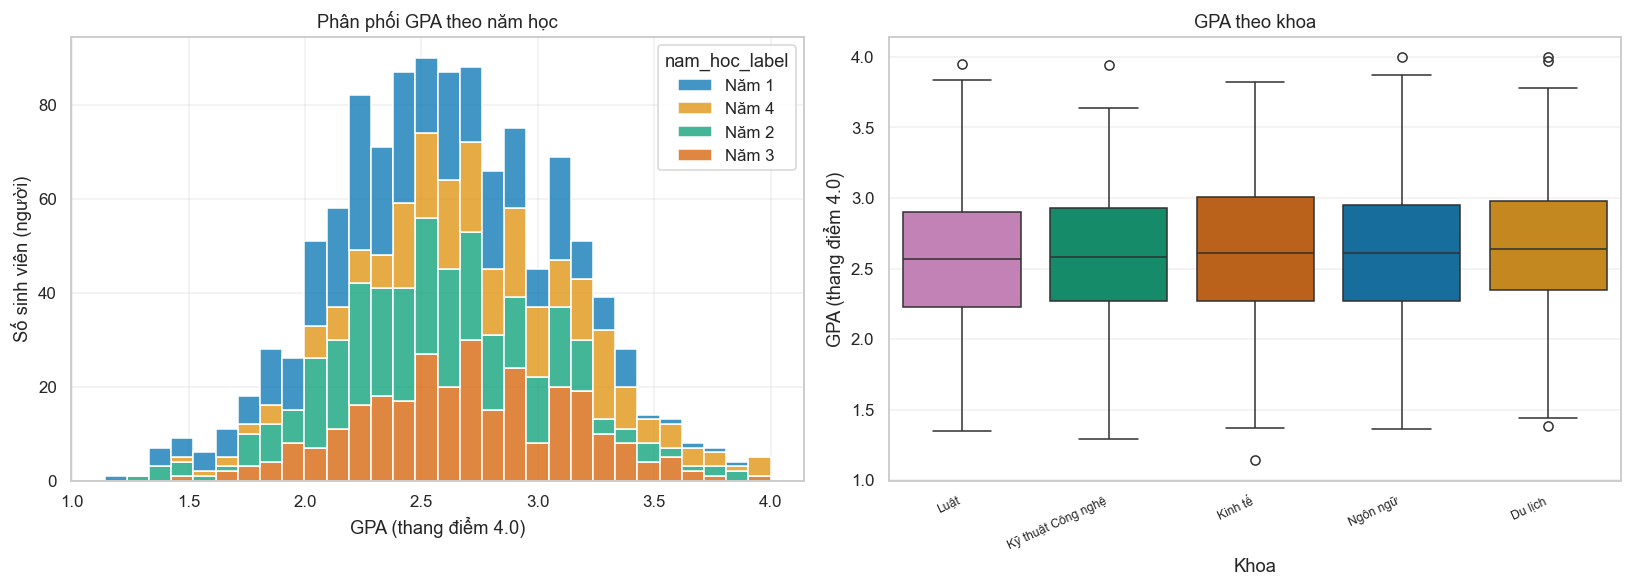

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

sv_plot = sv.copy()
sv_plot["nam_hoc_label"] = "Năm " + sv_plot["nam_hoc"].astype(str)

sns.histplot(data=sv_plot, x="gpa", hue="nam_hoc_label", bins=30,
             multiple="stack", palette="colorblind", ax=axa)
axa.set_xlabel("GPA (thang điểm 4.0)")
axa.set_ylabel("Số sinh viên (người)")
axa.set_title("Phân phối GPA theo năm học")

order = sv.groupby("khoa")["gpa"].median().sort_values().index.tolist()
sns.boxplot(data=sv, x="khoa", y="gpa", order=order, hue="khoa",
            palette="colorblind", legend=False, ax=axb)
axb.set_xlabel("Khoa")
axb.set_ylabel("GPA (thang điểm 4.0)")
axb.set_title("GPA theo khoa")
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")


### Bản nào truyền đạt tốt hơn?

1. Bản Seaborn bổ sung cách tách phân phối GPA theo từng năm học bằng `hue`, giúp so sánh nhóm trực tiếp hơn.
2. Matplotlib kiểm soát chi tiết hơn cách bố trí, nhãn và các thành phần của biểu đồ.
3. Seaborn thường cần ít dòng code hơn cho biểu đồ phân nhóm; đổi lại Matplotlib cho khả năng kiểm soát từng thành phần tốt hơn.
4. Nếu đưa vào báo cáo, chọn bản giúp người đọc trả lời câu hỏi nhanh nhất; với mục tiêu so sánh GPA theo năm và theo khoa, bản Seaborn thuận tiện hơn vì thể hiện nhóm trực tiếp.


---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [x] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [x] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [x] `banhang_sach.csv` — 900 dòng × 8 cột
- [x] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [x] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [x] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [x] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [x] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [x] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [x] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [x] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.

### Nộp bài
---
**Link kho Git của tôi:**
`https://github.com/shengs1/p4aids-2026/tree/main/BT2`

<small>*Họ tên:* Nguyễn Đức Thịnh &nbsp;|&nbsp; *MSSV:* 2305CT2084 &nbsp;|&nbsp; *Lớp:* 2305CT2084</small>
---